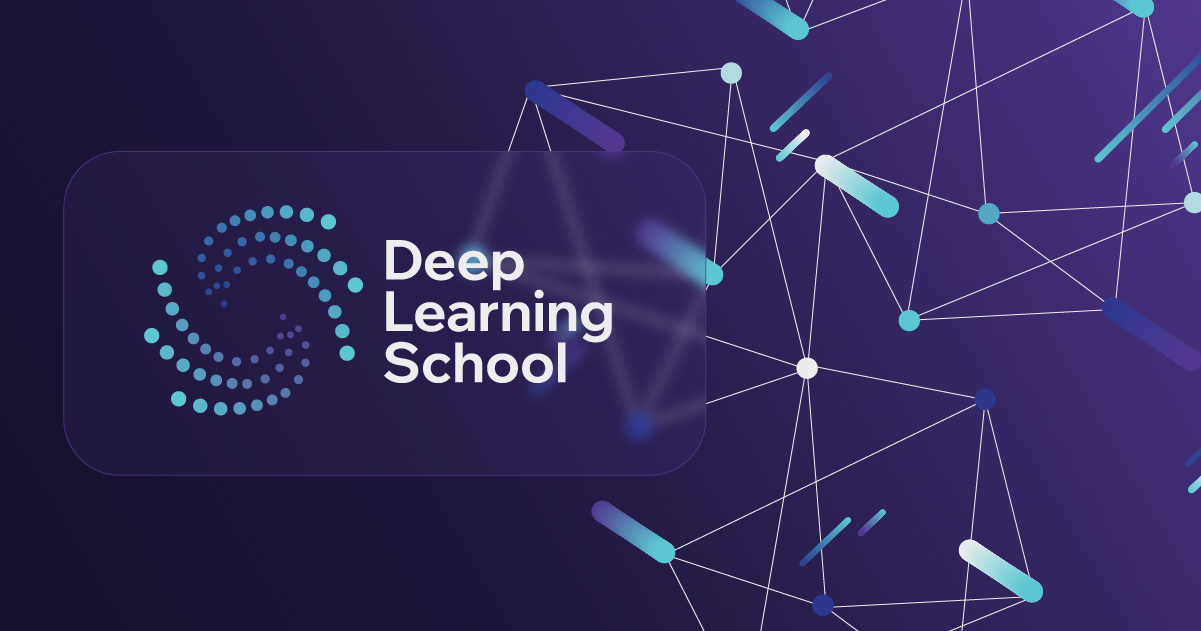

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

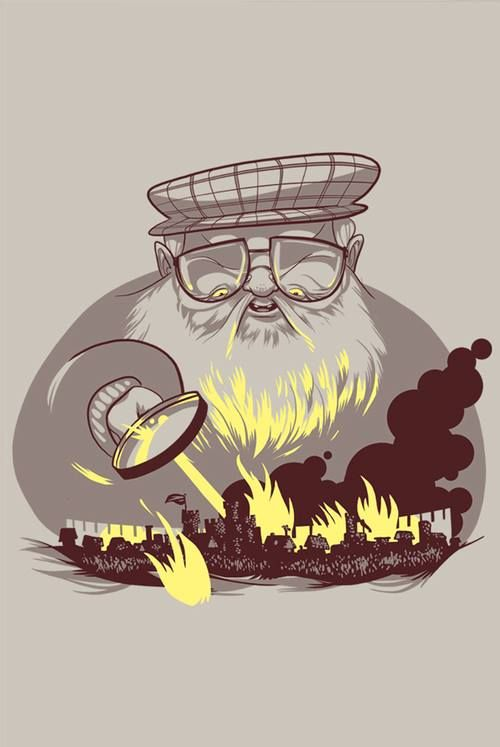

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [1]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 86.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 12.3MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [3]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')

In [4]:
data

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Archmaester,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.160535,1
1554,Masha Heddle,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.040134,0
1555,Matthos Seaworth,NaN,1,NaN,NaN,NaN,NaN,NaN,House Seaworth,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.076923,0


Посмотрите, какие типы данных представлены в нашем датасете

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [5]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [6]:
data.describe(include = ['number']).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

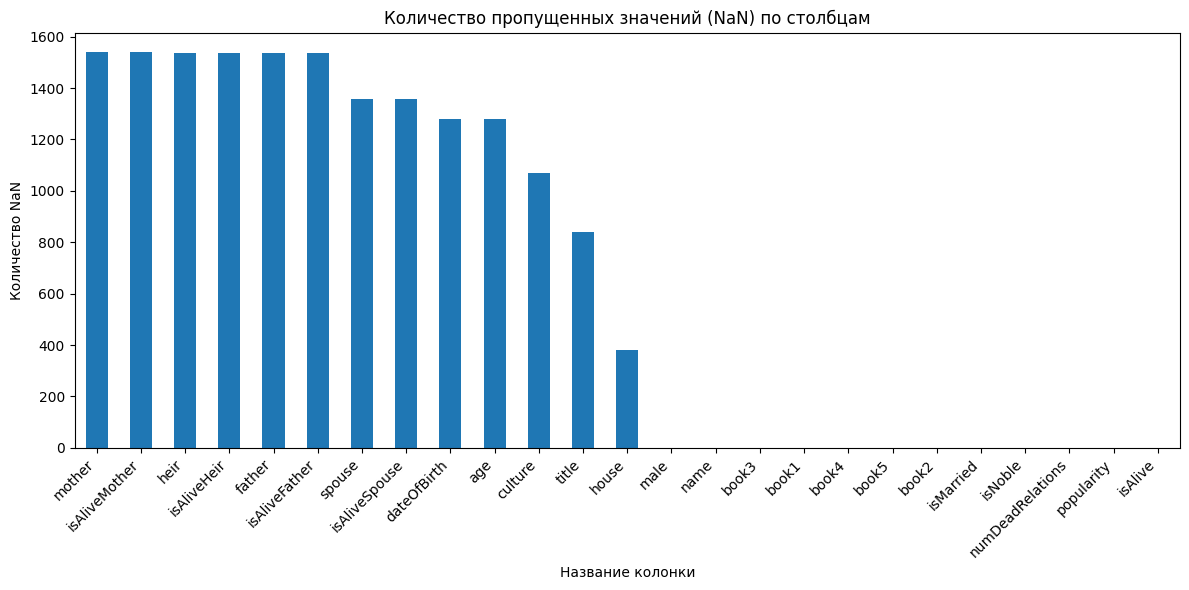

In [7]:
# Подсчет количества NaN в каждом столбце и сортировка по убыванию
nan_counts = data.isnull().sum().sort_values(ascending=False)

# Построение вертикальной гистограммы
plt.figure(figsize=(12, 6))
nan_counts.plot(kind='bar')
plt.xlabel('Название колонки')
plt.ylabel('Количество NaN')
plt.title('Количество пропущенных значений (NaN) по столбцам')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Вывод**

В столбцах mother, isAliveMother, heir, isAliveHeir, father, isAliveFather больше всего Nan-значений. Практически во всех объектах в этих стоблцах присутствуют данные значения.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

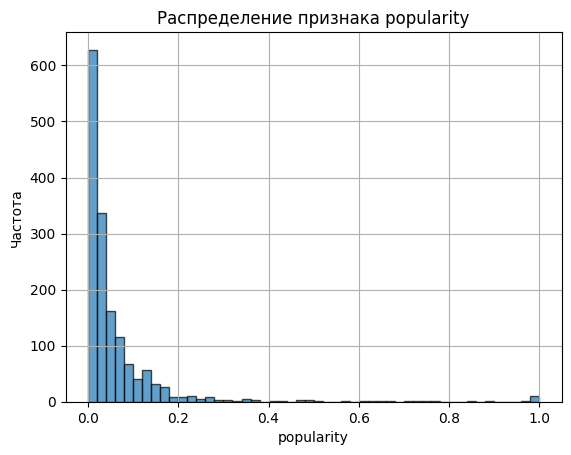

In [8]:
# Построение гистограммы для признака popularity с 50 интервалами
data['popularity'].hist(bins=50, edgecolor='black', alpha=0.7)

# Добавление заголовка и подписей осей
plt.title('Распределение признака popularity')
plt.xlabel('popularity')
plt.ylabel('Частота')

# Отображение графика
plt.show()

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


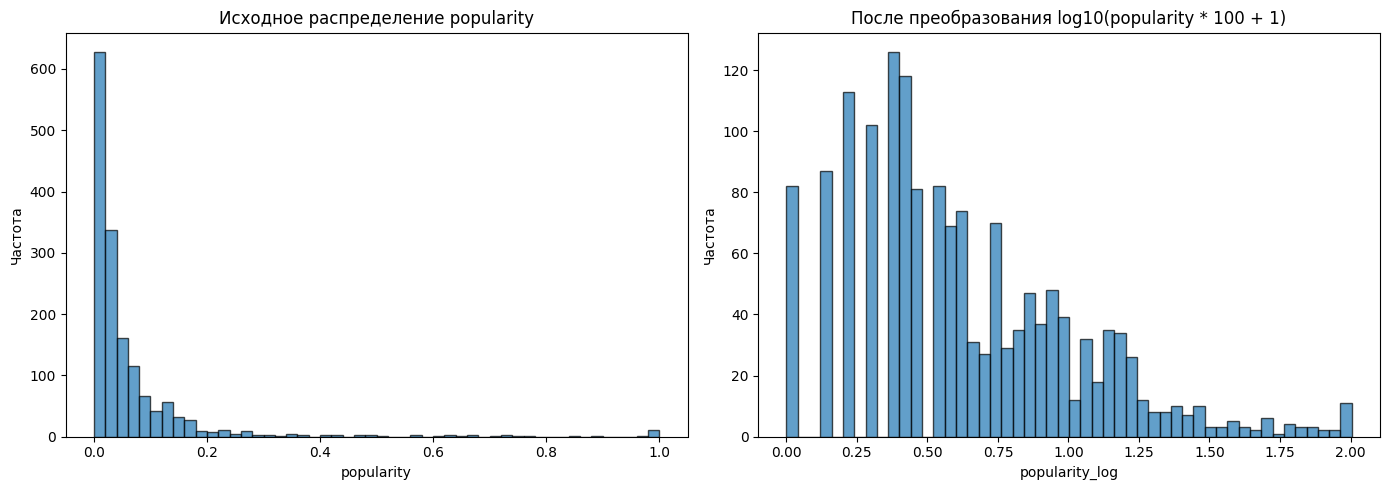

Статистика исходного признака:
count    1557.000000
mean        0.062400
std         0.121416
min         0.000000
25%         0.013378
50%         0.023411
75%         0.063545
max         1.000000
Name: popularity, dtype: float64


Статистика преобразованного признака (M=100):
count    1557.000000
mean        0.621287
std         0.402654
min         0.000000
25%         0.368806
50%         0.523894
75%         0.866554
max         2.004321
Name: popularity_log, dtype: float64


In [9]:
import numpy as np


# Выбор значения M
M = 100

# Создание нового признака с логарифмическим преобразованием
data['popularity_log'] = np.log10(data['popularity'] * M + 1)

# Сравнение распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Исходное распределение
axes[0].hist(data['popularity'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Исходное распределение popularity')
axes[0].set_xlabel('popularity')
axes[0].set_ylabel('Частота')

# Преобразованное распределение
axes[1].hist(data['popularity_log'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title(f'После преобразования log10(popularity * {M} + 1)')
axes[1].set_xlabel('popularity_log')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Вывод статистики для сравнения
print("Статистика исходного признака:")
print(data['popularity'].describe())
print("\n" + "="*50 + "\n")
print(f"Статистика преобразованного признака (M={M}):")
print(data['popularity_log'].describe())

В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

Анализ признака numDeadRelations:
numDeadRelations
0     1488
1       24
2        4
3        4
4        7
5       10
6        3
7        7
8        2
9        1
10       4
11       1
12       1
15       1
Name: count, dtype: int64

Статистика:
count    1557.000000
mean        0.187540
std         1.114648
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        15.000000
Name: numDeadRelations, dtype: float64


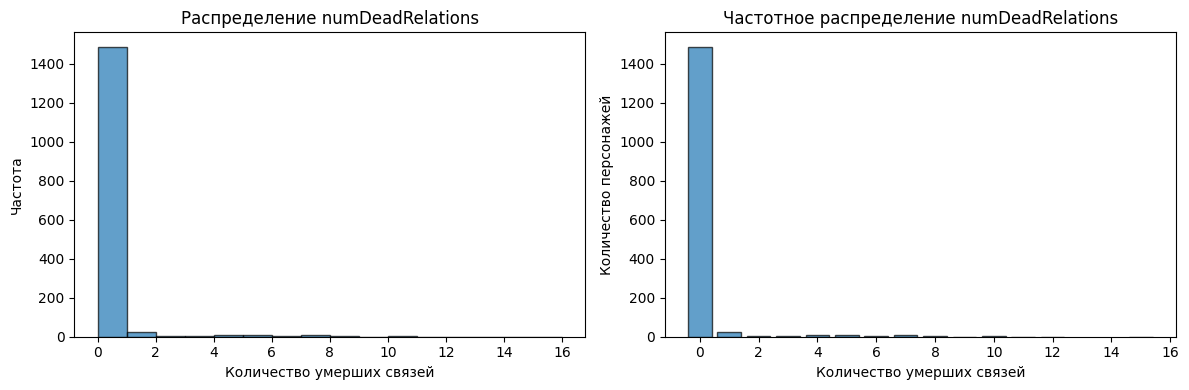



Результат бинаризации:
boolDeadRelations
0    1488
1      69
Name: count, dtype: int64

Процентное распределение:
boolDeadRelations
0    95.568401
1     4.431599
Name: proportion, dtype: float64


Пример первых 10 строк:
      numDeadRelations  boolDeadRelations
S.No                                     
1                   11                  1
2                    1                  1
3                    0                  0
4                    0                  0
5                    0                  0
6                    5                  1
7                    0                  0
8                    5                  1
9                    0                  0
10                   0                  0


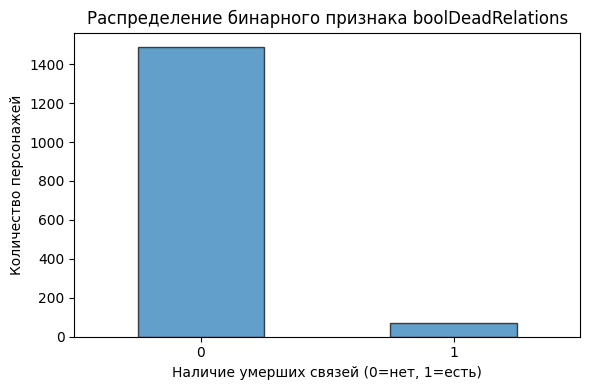

In [10]:
# Анализ исходного распределения
print("Анализ признака numDeadRelations:")
print(data['numDeadRelations'].value_counts().sort_index())
print("\nСтатистика:")
print(data['numDeadRelations'].describe())

# Визуализация исходного распределения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма
axes[0].hist(data['numDeadRelations'], bins=range(0, int(data['numDeadRelations'].max())+2),
             edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение numDeadRelations')
axes[0].set_xlabel('Количество умерших связей')
axes[0].set_ylabel('Частота')

# Столбчатая диаграмма для наглядности (т.к. много нулей)
counts = data['numDeadRelations'].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, edgecolor='black', alpha=0.7)
axes[1].set_title('Частотное распределение numDeadRelations')
axes[1].set_xlabel('Количество умерших связей')
axes[1].set_ylabel('Количество персонажей')

plt.tight_layout()
plt.show()

# Создание бинарного признака boolDeadRelations
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)

# Проверка результата
print("\n" + "="*50)
print("\nРезультат бинаризации:")
print(data['boolDeadRelations'].value_counts())
print(f"\nПроцентное распределение:")
print(data['boolDeadRelations'].value_counts(normalize=True) * 100)

# Сравнение исходного и нового признака
print("\n" + "="*50)
print("\nПример первых 10 строк:")
print(data[['numDeadRelations', 'boolDeadRelations']].head(10))

# Визуализация нового бинарного признака
plt.figure(figsize=(6, 4))
data['boolDeadRelations'].value_counts().plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Распределение бинарного признака boolDeadRelations')
plt.xlabel('Наличие умерших связей (0=нет, 1=есть)')
plt.ylabel('Количество персонажей')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [11]:
data['age_value'] = data['age'].fillna(0)
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [12]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [13]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [14]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [15]:
# По аналогии с примером выше инвертируйте словарь cultures_grouped
cultures_grouped_inverted = {}

for k in cultures_grouped.keys():
    for v in cultures_grouped[k]:
        cultures_grouped_inverted.update({v: k})

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [16]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [17]:
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [18]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
culture,51
dateOfBirth,105
mother,16
father,19
heir,20
house,315
spouse,186


In [19]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
data.describe(include = [np.number]).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.000000,2
dateOfBirth,279.0,-25.0,299.000000,105
book1,1557.0,0.0,1.000000,2
book2,1557.0,0.0,1.000000,2
book3,1557.0,0.0,1.000000,2
book4,1557.0,0.0,1.000000,2
book5,1557.0,0.0,1.000000,2
isAliveMother,18.0,0.0,1.000000,2
isAliveFather,22.0,0.0,1.000000,2
isAliveHeir,21.0,0.0,1.000000,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [20]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:

data.groupby('isAliveSpouse', dropna = False)['isAlive'].mean()
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveSpouse', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveSpouse,,
0.0,0.619048,42
1.0,0.753165,158
NaN,0.786293,1357


**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [21]:
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isNoble,age,numDeadRelations,popularity,isAlive,popularity_log,boolDeadRelations,age_value,age_no_data,culture_grouped
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,0,NaN,11,0.605351,0,1.789123,1,0.0,1,culture_no_data
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,1,97.0,1,0.896321,1,1.957282,1,97.0,0,the Isles and Rivers
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,1,NaN,0,0.267559,1,1.443355,0,0.0,1,culture_no_data
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,1,23.0,0,0.183946,0,1.287682,0,23.0,0,culture_no_data
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,1,29.0,0,0.043478,1,0.728177,0,29.0,0,Dorne


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1557 non-null   object 
 1   title              717 non-null    object 
 2   male               1557 non-null   int64  
 3   culture            488 non-null    object 
 4   dateOfBirth        279 non-null    float64
 5   mother             18 non-null     object 
 6   father             22 non-null     object 
 7   heir               21 non-null     object 
 8   house              1176 non-null   object 
 9   spouse             200 non-null    object 
 10  book1              1557 non-null   int64  
 11  book2              1557 non-null   int64  
 12  book3              1557 non-null   int64  
 13  book4              1557 non-null   int64  
 14  book5              1557 non-null   int64  
 15  isAliveMother      18 non-null     float64
 16  isAliveFather      22 non-nul

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
# 1. Признак name - удаляем (обычно не используется в модели, так как уникален для каждого персонажа)
data = data.drop('name', axis=1)

In [25]:
# 2. Признак title - кодируем LabelEncoder
data['title'] = data['title'].fillna('no_title')  # Заполняем пропуски
le_title = LabelEncoder()
data['title_encoded'] = le_title.fit_transform(data['title'])

In [26]:
# 3. Признак culture - используем готовую culture_grouped (уже обработана)
# Но можно и оригинальную культуру закодировать для сравнения
data['culture'] = data['culture'].fillna('unknown')
le_culture = LabelEncoder()
data['culture_encoded'] = le_culture.fit_transform(data['culture'])

In [27]:
# 4. Признак culture_grouped - уже обработан и готов для one-hot или LabelEncoder
# Для линейных моделей лучше one-hot, но можно и LabelEncoder для начала
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')
le_culture_grouped = LabelEncoder()
data['culture_grouped_encoded'] = le_culture_grouped.fit_transform(data['culture_grouped'])

In [28]:
# 5. Признаки mother, father, heir, spouse - кодируем LabelEncoder
# Заполняем пропуски специальным значением
family_features = ['mother', 'father', 'heir', 'spouse']

for feature in family_features:
    data[feature] = data[feature].fillna('unknown')
    le = LabelEncoder()
    data[f'{feature}_encoded'] = le.fit_transform(data[feature])

    # Выводим информацию о кодировании
    print(f"\nПризнак {feature}:")
    print(f"  Уникальных значений: {data[feature].nunique()}")
    print(f"  Примеры: {list(data[feature].value_counts().head(3).index)}")



Признак mother:
  Уникальных значений: 17
  Примеры: ['unknown', 'Rhaenyra Targaryen', 'Cersei Lannister']

Признак father:
  Уникальных значений: 20
  Примеры: ['unknown', 'Daemon Targaryen', 'Robert Baratheon']

Признак heir:
  Уникальных значений: 21
  Примеры: ['unknown', 'Jaehaerys Targaryen', 'Aegon IV Targaryen']

Признак spouse:
  Уникальных значений: 187
  Примеры: ['unknown', 'Walder Frey', 'Craster']


In [29]:
# 6. Признак house - кодируем LabelEncoder
data['house'] = data['house'].fillna('no_house')
le_house = LabelEncoder()
data['house_encoded'] = le_house.fit_transform(data['house'])

In [30]:
data.head()

,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,book1,...,age_no_data,culture_grouped,title_encoded,culture_encoded,culture_grouped_encoded,mother_encoded,father_encoded,heir_encoded,spouse_encoded,house_encoded
S.No,,,,,,,,,,,,,,,,,,,,,
1,no_title,1,unknown,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,no_house,unknown,0,...,1,culture_no_data,194,50,4,11,8,0,186,314
2,Lord of the Crossing,1,Rivermen,208.0,unknown,unknown,unknown,House Frey,Perra Royce,1,...,0,the Isles and Rivers,115,31,6,16,19,20,134,106
3,Ser,1,unknown,NaN,unknown,unknown,unknown,House Swyft,unknown,0,...,1,culture_no_data,163,50,4,16,19,20,186,244
4,Queen,0,unknown,82.0,unknown,unknown,unknown,House Arryn,Viserys I Targaryen,0,...,0,culture_no_data,145,50,4,16,19,20,176,21
5,Greenstone,0,Dornish,276.0,unknown,unknown,unknown,House Santagar,Eldon Estermont,0,...,0,Dorne,53,7,0,16,19,20,56,219


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    1557 non-null   object 
 1   male                     1557 non-null   int64  
 2   culture                  1557 non-null   object 
 3   dateOfBirth              279 non-null    float64
 4   mother                   1557 non-null   object 
 5   father                   1557 non-null   object 
 6   heir                     1557 non-null   object 
 7   house                    1557 non-null   object 
 8   spouse                   1557 non-null   object 
 9   book1                    1557 non-null   int64  
 10  book2                    1557 non-null   int64  
 11  book3                    1557 non-null   int64  
 12  book4                    1557 non-null   int64  
 13  book5                    1557 non-null   int64  
 14  isAliveMother            18 n

In [32]:
# Список категориальных колонок, которые уже обработаны и больше не нужны
columns_to_drop = ['title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse', 'culture_grouped']

# Удаляем колонки
data = data.drop(columns=columns_to_drop)

# Проверяем результат
print("Оставшиеся колонки после удаления:")
print(data.columns.tolist())
print(f"\nРазмерность датасета: {data.shape}")

Оставшиеся колонки после удаления:
['male', 'dateOfBirth', 'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity', 'isAlive', 'popularity_log', 'boolDeadRelations', 'age_value', 'age_no_data', 'title_encoded', 'culture_encoded', 'culture_grouped_encoded', 'mother_encoded', 'father_encoded', 'heir_encoded', 'spouse_encoded', 'house_encoded']

Размерность датасета: (1557, 29)


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   male                     1557 non-null   int64  
 1   dateOfBirth              279 non-null    float64
 2   book1                    1557 non-null   int64  
 3   book2                    1557 non-null   int64  
 4   book3                    1557 non-null   int64  
 5   book4                    1557 non-null   int64  
 6   book5                    1557 non-null   int64  
 7   isAliveMother            18 non-null     float64
 8   isAliveFather            22 non-null     float64
 9   isAliveHeir              21 non-null     float64
 10  isAliveSpouse            200 non-null    float64
 11  isMarried                1557 non-null   int64  
 12  isNoble                  1557 non-null   int64  
 13  age                      279 non-null    float64
 14  numDeadRelations         1557

In [34]:
# Список признаков с большим количеством пропусков
columns_with_missing = ['dateOfBirth', 'isAliveMother', 'isAliveFather',
                        'isAliveHeir', 'isAliveSpouse', 'age']

# Удаляем эти колонки
data = data.drop(columns=columns_with_missing)

print(f"Удалено колонок: {len(columns_with_missing)}")
print(f"Осталось колонок: {data.shape[1]}")

Удалено колонок: 6
Осталось колонок: 23


**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

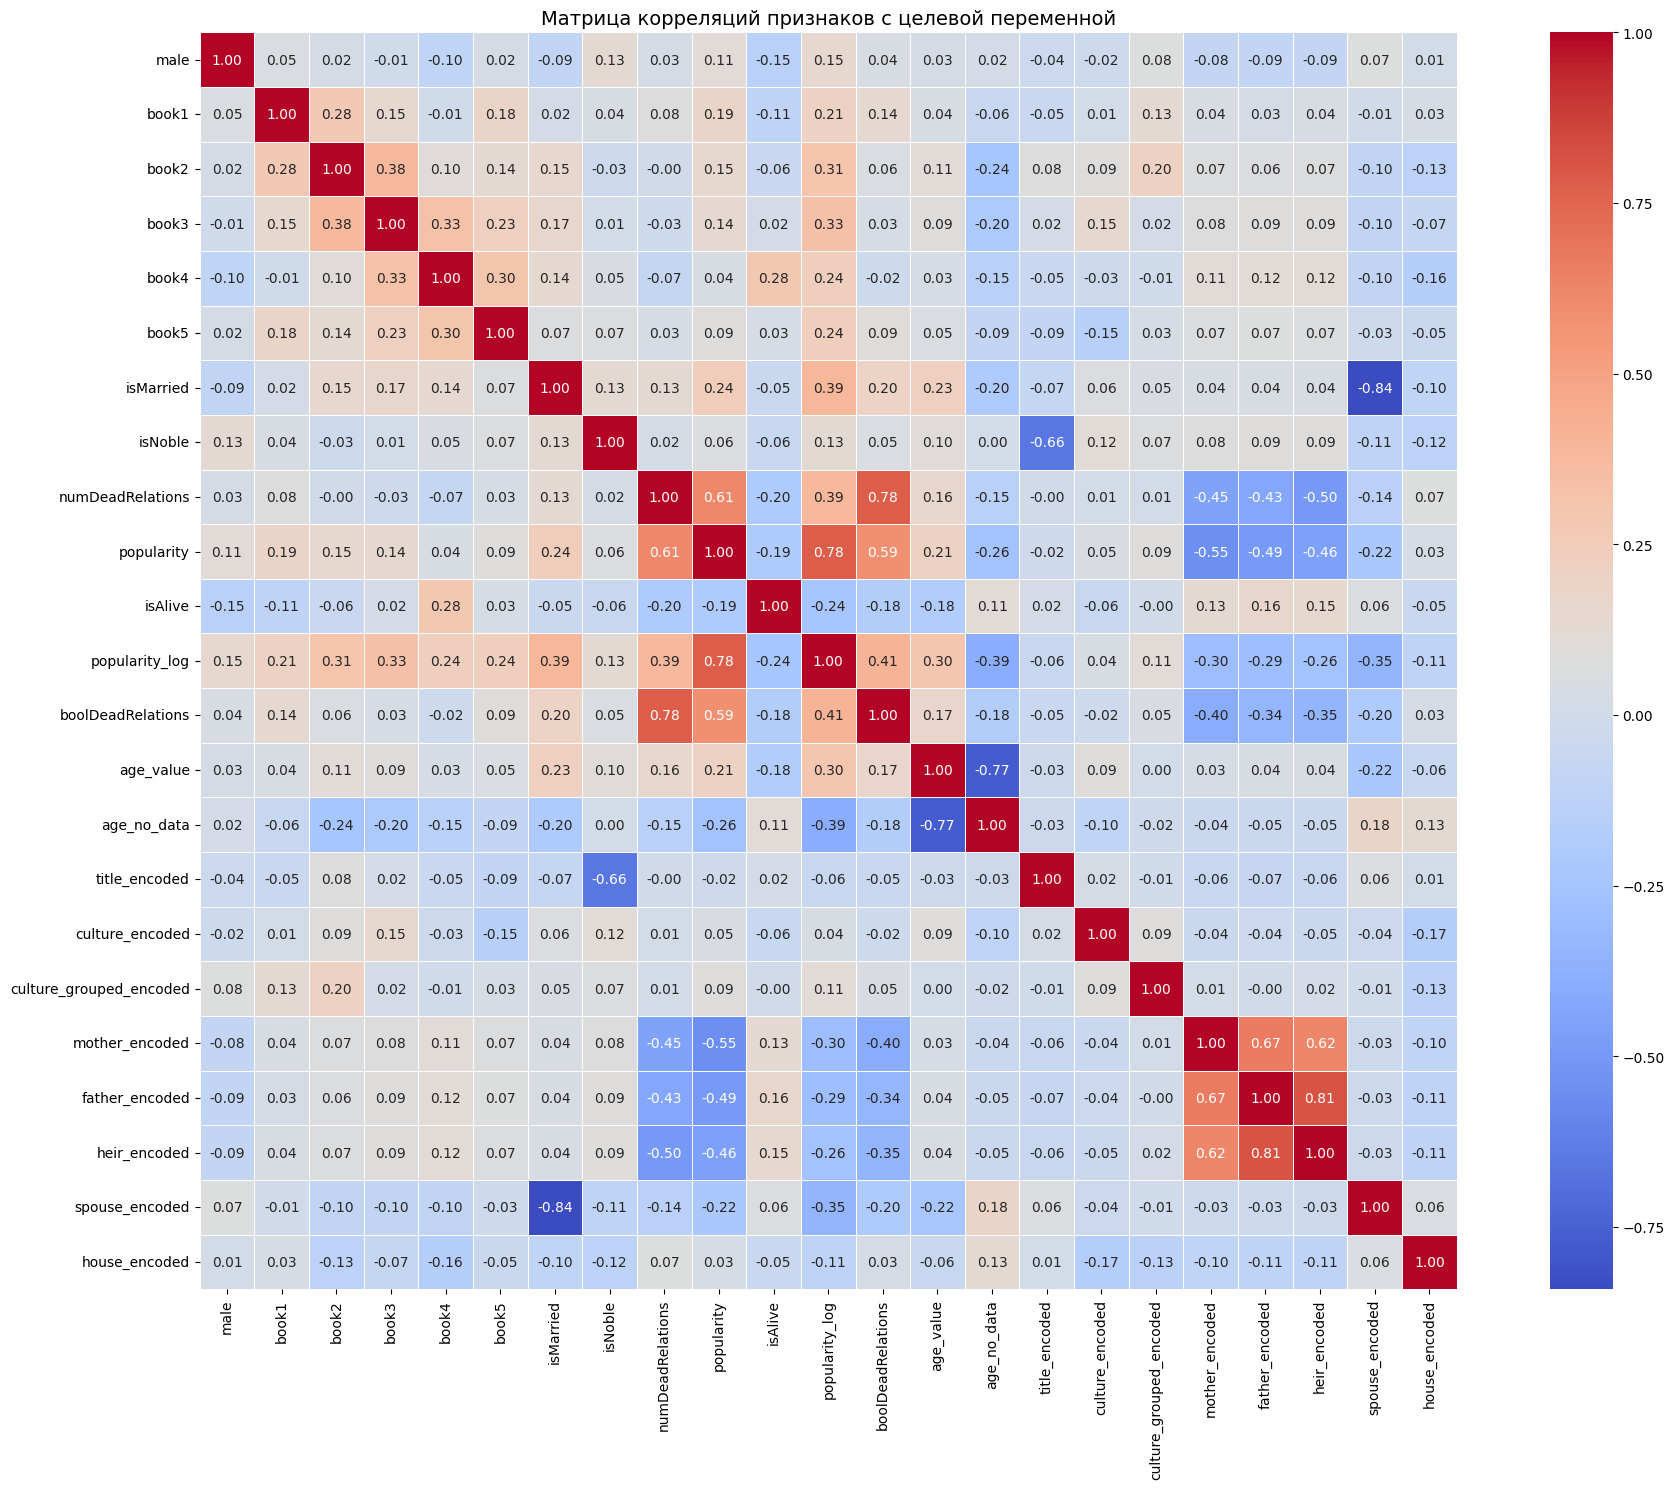

In [35]:
correlation_matrix = data.corr()

# Настраиваем размер графика
plt.figure(figsize=(20, 15))

# Строим тепловую карту
# annot=True — показывать значения в ячейках
# cmap='coolwarm' — цветовая схема (красный = положительная, синий = отрицательная)
# fmt='.2f' — формат вывода чисел (2 знака после запятой)
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5,
            square=True)

plt.title('Матрица корреляций признаков с целевой переменной', fontsize=14)
plt.tight_layout()
plt.show()

**Вывод**

Как видим целевой признак слабо коррелирует с остальными признаками

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [36]:
# Берем все числовые колонки, кроме целевой
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Удаляем целевую переменную из списка признаков
if 'isAlive' in numeric_cols:
    numeric_cols.remove('isAlive')

X = data[numeric_cols]
y = data['isAlive']

**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
# не забудьте в функции train_test_split задать параметр random_state,
# чтобы обеспечить повторяемость разбиения выборки на train и validation части.
# Это позволит сравнивать метрики моделей с различными методами подготовки признаков
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,          # 20% данных пойдет на валидацию
    random_state=42,        # фиксируем случайность для воспроизводимости
    stratify=y              # сохраняем пропорции классов в train и val
)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [39]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Шаг 1: создание модели
# Параметры:
# - random_state=42 для воспроизводимости
# - max_iter=1000 для гарантии сходимости (по умолчанию 100 может не хватить)
# - solver='lbfgs' — хороший выбор для небольших и средних датасетов
model = LogisticRegression(random_state=42, max_iter=1000)

# Шаг 2: обучение модели
model.fit(X_train, y_train)

# Шаг 3: предсказание на валидационных данных
y_pred = model.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [41]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [42]:
# Шаг 3. Предсказание на тестовых данных

# см. предыдущий шаг

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7885


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

**Попробуем обучить Случайный лес**

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Базовый RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # количество деревьев
    max_depth=None,        # максимальная глубина (None - без ограничений)
    min_samples_split=2,   # минимальное количество образцов для разделения узла
    min_samples_leaf=1,    # минимальное количество образцов в листе
    random_state=42,       # для воспроизводимости
    n_jobs=-1,            # используем все ядра процессора
    verbose=1              # выводим прогресс обучения
)

rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.1s


Accuracy: 0.7917


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


Accuracy: 0.7917 - лучше чем логистическая регрессия

Эту модель и будем использовать на тестовом датасете

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [44]:
data_test = pd.read_csv('game_of_thrones_test.csv', index_col='S.No')

In [45]:
data_test

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1558,Melissa Blackwood,NaN,0,NaN,156.0,NaN,NaN,NaN,House Blackwood,NaN,...,1,NaN,NaN,NaN,NaN,0,0,100.0,0,0.050167
1559,Melisandre,NaN,0,Asshai,NaN,NaN,NaN,NaN,R'hllor,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.745819
1560,Merrit,NaN,0,NaN,NaN,NaN,NaN,NaN,Brotherhood without banners,NaN,...,0,NaN,NaN,NaN,NaN,0,0,NaN,0,0.010033
1561,Meryn Trant,Ser,1,NaN,NaN,NaN,NaN,NaN,House Trant,NaN,...,1,NaN,NaN,NaN,NaN,0,1,NaN,0,0.220736
1562,Merrett Frey,NaN,1,Riverlands,262.0,NaN,NaN,NaN,House Frey,Mariya Darry,...,1,NaN,NaN,NaN,1.0,1,0,38.0,0,0.434783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,Luwin,NaN,1,Westeros,NaN,NaN,NaN,NaN,House Stark,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.351171
1943,Reek,NaN,1,NaN,NaN,NaN,NaN,NaN,House Bolton,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.096990
1944,Symeon Star-Eyes,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.030100


По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [46]:
#Подсказка
data_test.loc[data_test['age']<0] # Находим данные с ошибками в дате рождения и возрасте

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1685,Doreah,NaN,0,Lysene,278279.0,NaN,NaN,NaN,House Targaryen,NaN,...,1,NaN,NaN,NaN,NaN,0,0,-277980.0,0,0.110368
1869,Rhaego,NaN,0,NaN,298299.0,NaN,NaN,NaN,House Targaryen,NaN,...,0,NaN,NaN,NaN,NaN,0,0,-298001.0,6,0.167224


In [47]:
#Вы можете аккуратно поправить тестовые данные, воспользовавшись, например следующим кодом:
data_test.loc[1685, 'dateOfBirth'] = 278.
# замены в строке 1685: dateOfBirth -> 278. и age -> 0.
data_test.loc[1685, 'age'] = 0.
# замены в строке 1869: dateOfBirth -> 299. и age -> 0.
data_test.loc[1869, 'dateOfBirth'] = 299.
data_test.loc[1869, 'age'] = 0.

In [48]:
data_test.loc[data_test['age']<0]

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,


Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [49]:
data_test['popularity_log'] = np.log10(data_test['popularity'] * M + 1)

data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)

data_test['age_value'] = data_test['age'].fillna(0)
data_test['age_no_data'] = [1 if np.isnan(x) else 0 for x in data_test['age']]

data_test['culture_grouped'] = data_test['culture'].str.lower().map(cultures_grouped_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

# 1. Признак name - удаляем (обычно не используется в модели, так как уникален для каждого персонажа)
data_test = data_test.drop('name', axis=1)

# 2. Признак title - кодируем LabelEncoder
data_test['title'] = data_test['title'].fillna('no_title')  # Заполняем пропуски
le_title = LabelEncoder()
data_test['title_encoded'] = le_title.fit_transform(data_test['title'])

# 3. Признак culture - используем готовую culture_grouped (уже обработана)
# Но можно и оригинальную культуру закодировать для сравнения
data_test['culture'] = data_test['culture'].fillna('unknown')
le_culture = LabelEncoder()
data_test['culture_encoded'] = le_culture.fit_transform(data_test['culture'])

# 4. Признак culture_grouped - уже обработан и готов для one-hot или LabelEncoder
# Для линейных моделей лучше one-hot, но можно и LabelEncoder для начала
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')
le_culture_grouped = LabelEncoder()
data_test['culture_grouped_encoded'] = le_culture_grouped.fit_transform(data_test['culture_grouped'])

# 5. Признаки mother, father, heir, spouse - кодируем LabelEncoder
# Заполняем пропуски специальным значением
family_features = ['mother', 'father', 'heir', 'spouse']

for feature in family_features:
    data_test[feature] = data_test[feature].fillna('unknown')
    le = LabelEncoder()
    data_test[f'{feature}_encoded'] = le.fit_transform(data_test[feature])

    # Выводим информацию о кодировании
    print(f"\nПризнак {feature}:")
    print(f"  Уникальных значений: {data_test[feature].nunique()}")
    print(f"  Примеры: {list(data_test[feature].value_counts().head(3).index)}")

# 6. Признак house - кодируем LabelEncoder
data_test['house'] = data_test['house'].fillna('no_house')
le_house = LabelEncoder()
data_test['house_encoded'] = le_house.fit_transform(data_test['house'])

# Список категориальных колонок, которые уже обработаны и больше не нужны
columns_to_drop = ['title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse', 'culture_grouped']

# Удаляем колонки
data_test = data_test.drop(columns=columns_to_drop)

# Проверяем результат
print("Оставшиеся колонки после удаления:")
print(data_test.columns.tolist())
print(f"\nРазмерность датасета: {data_test.shape}")

# Список признаков с большим количеством пропусков
columns_with_missing = ['dateOfBirth', 'isAliveMother', 'isAliveFather',
                        'isAliveHeir', 'isAliveSpouse', 'age']

# Удаляем эти колонки
data_test = data_test.drop(columns=columns_with_missing)

print(f"Удалено колонок: {len(columns_with_missing)}")
print(f"Осталось колонок: {data_test.shape[1]}")



Признак mother:
  Уникальных значений: 4
  Примеры: ['unknown', 'Dyanna Dayne', 'Daenaera Velaryon']

Признак father:
  Уникальных значений: 5
  Примеры: ['unknown', 'Maekar I Targaryen', 'Quellon Greyjoy']

Признак heir:
  Уникальных значений: 3
  Примеры: ['unknown', 'Duncan Targaryen', 'Theon Greyjoy']

Признак spouse:
  Уникальных значений: 76
  Примеры: ['unknown', 'Tyrion Lannister', 'Hoster Tully']
Оставшиеся колонки после удаления:
['male', 'dateOfBirth', 'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity', 'popularity_log', 'boolDeadRelations', 'age_value', 'age_no_data', 'title_encoded', 'culture_encoded', 'culture_grouped_encoded', 'mother_encoded', 'father_encoded', 'heir_encoded', 'spouse_encoded', 'house_encoded']

Размерность датасета: (389, 28)
Удалено колонок: 6
Осталось колонок: 22


In [53]:
y_res = rf_model.predict(data_test)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


In [54]:
y_res

array([0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [50]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.0MB/s]


In [51]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [52]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


In [55]:
submission['isAlive'] = y_res

In [56]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,1
1561,1
1562,0
...,...
1942,0
1943,0
1944,1


Как сохранить измененный Pandas DataFrame в csv файл:

In [57]:
submission.to_csv("/content/new_submission.csv", index=False)